# Airline Crew Sequences Meet Bad Weather
### EPPS–American Airlines Data Challenge — GROW 26.2

**Goal:** Identify airport pairs **(A, B)** that should not appear in the same pilot sequence `A → DFW → B` because both legs are weather-prone, creating cascading delays, duty violations, and fatigue risk.

**Approach:** XGBoost classifier trained on 2018–2024 BTS flight data + statistical significance filtering (Wilson CI + FDR correction) + real-time METAR weather adjustment.

---
### Pipeline
```
BTS On-Time Data (5 years)
       ↓
Airport-level weather risk features (per airport × month)
       ↓
Pair construction: A→DFW arrivals × DFW→B departures (same day, 30–240 min window)
       ↓
Aggregate to (airport_A, airport_B, Month, Year) → 574k rows
       ↓
XGBoost — time-split train (2018–2023) / val (2024)
       ↓
Statistical significance (Wilson CI + FDR) → 26,880 significant pair×month combos
       ↓
Real-time adjustment via AWC METAR API
```

In [1]:
import os, sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import xgboost as xgb
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score, average_precision_score

from significance import compute_significance, top_significant_pairs, wilson_ci, MIN_N

PROC  = '../data/processed'
PLOTS = f'{PROC}/plots'
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

---
## 1. Dataset Overview

In [2]:
df = pd.read_parquet(f'{PROC}/sequence_features.parquet')

print(f"Total pair×month×year rows : {len(df):,}")
print(f"Unique inbound airports (A): {df['airport_A'].nunique()}")
print(f"Unique outbound airports (B): {df['airport_B'].nunique()}")
print(f"Years covered:              {sorted(df['Year'].unique())}")
print(f"High-risk rate (overall):   {df['target'].mean():.1%}")
df[['airport_A','airport_B','Month','Year','observed_bad_rate','n_sequences','target']].head(5)

Total pair×month×year rows : 574,361
Unique inbound airports (A): 132
Unique outbound airports (B): 132
Years covered:              [np.int32(2018), np.int32(2019), np.int32(2022), np.int32(2023), np.int32(2024)]
High-risk rate (overall):   50.0%


,airport_A,airport_B,Month,Year,observed_bad_rate,n_sequences,target
0,ABQ,AGS,4,2019,0.000000,3,0
1,ABQ,AGS,4,2022,0.000000,5,0
2,ABQ,AGS,4,2023,0.250000,8,1
3,ABQ,AGS,4,2024,0.222222,9,1
4,ABQ,ALB,1,2024,0.161290,31,0


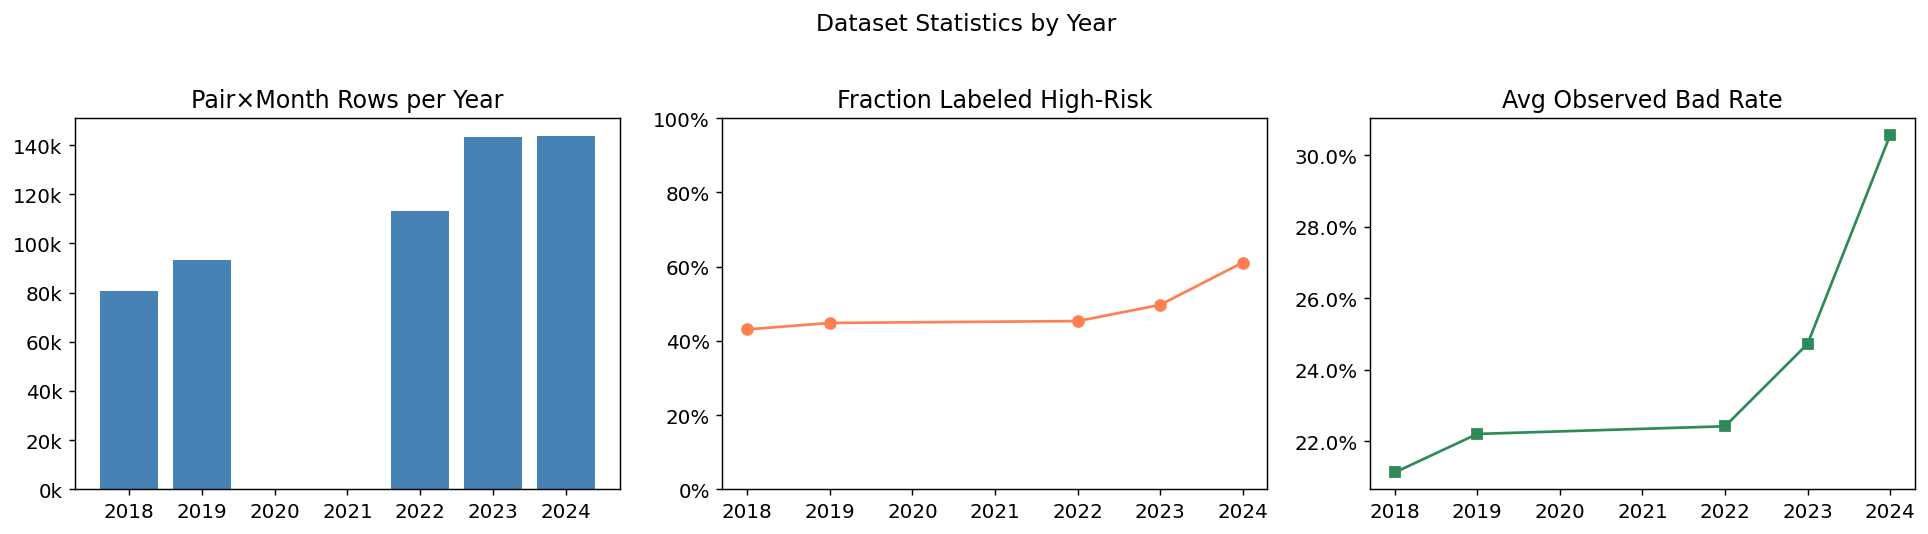

In [3]:
# Pair×month rows and high-risk rate by year
by_year = df.groupby('Year').agg(
    n_pairs=('target','count'),
    high_risk_rate=('target','mean'),
    avg_bad_rate=('observed_bad_rate','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(by_year['Year'], by_year['n_pairs'], color='steelblue')
axes[0].set_title('Pair×Month Rows per Year')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))

axes[1].plot(by_year['Year'], by_year['high_risk_rate'], 'o-', color='coral')
axes[1].set_title('Fraction Labeled High-Risk')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0,1)

axes[2].plot(by_year['Year'], by_year['avg_bad_rate'], 's-', color='seagreen')
axes[2].set_title('Avg Observed Bad Rate')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Dataset Statistics by Year', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Statistical Significance

Before looking at any results we apply rigorous significance testing so we only report pairs with **real signal**, not noise.

| Step | Method | Purpose |
|---|---|---|
| Wilson CI | Exact binomial CI on observed bad rate | Confidence bounds on each pair's estimate |
| Chi-square | H₀: pair rate == baseline rate | Is this pair actually worse? |
| BH-FDR | Benjamini-Hochberg correction | Controls false discovery rate across 161k tests |
| Min n | n ≥ 30 per pair×month | Discard pairs with too few observations |

In [4]:
pair_scores = pd.read_parquet(f'{PROC}/pair_risk_scores.parquet')

sig_df = compute_significance(pair_scores)

# Enrich with pair-level features from sequence_features
pair_feat_cols = [c for c in ['airport_A','airport_B','Month',
                               'pair_combined_weather_rate','pair_max_weather_rate',
                               'pair_weather_rate_sum','median_turnaround_min'] if c in df.columns]
pair_feats = df[pair_feat_cols].drop_duplicates(subset=['airport_A','airport_B','Month'])
sig_df = sig_df.merge(pair_feats, on=['airport_A','airport_B','Month'], how='left')

print(f"\nTotal pairs tested:          {len(sig_df):,}")
print(f"Pairs with sufficient data:  {(sig_df['n_sequences'] >= MIN_N).sum():,}")
print(f"Significantly high-risk:     {sig_df['significant'].sum():,}")
print(f"Baseline bad rate:           {sig_df['baseline_rate'].iloc[0]:.1%}")

Baseline bad rate:       0.259 (25.9%)
Pairs tested:            160,974
Pairs with n >= 30:    135,698
Significant (FDR-adj):   26,880
Significant high-risk:   26,880

Total pairs tested:          160,974
Pairs with sufficient data:  135,698
Significantly high-risk:     26,880
Baseline bad rate:           25.9%


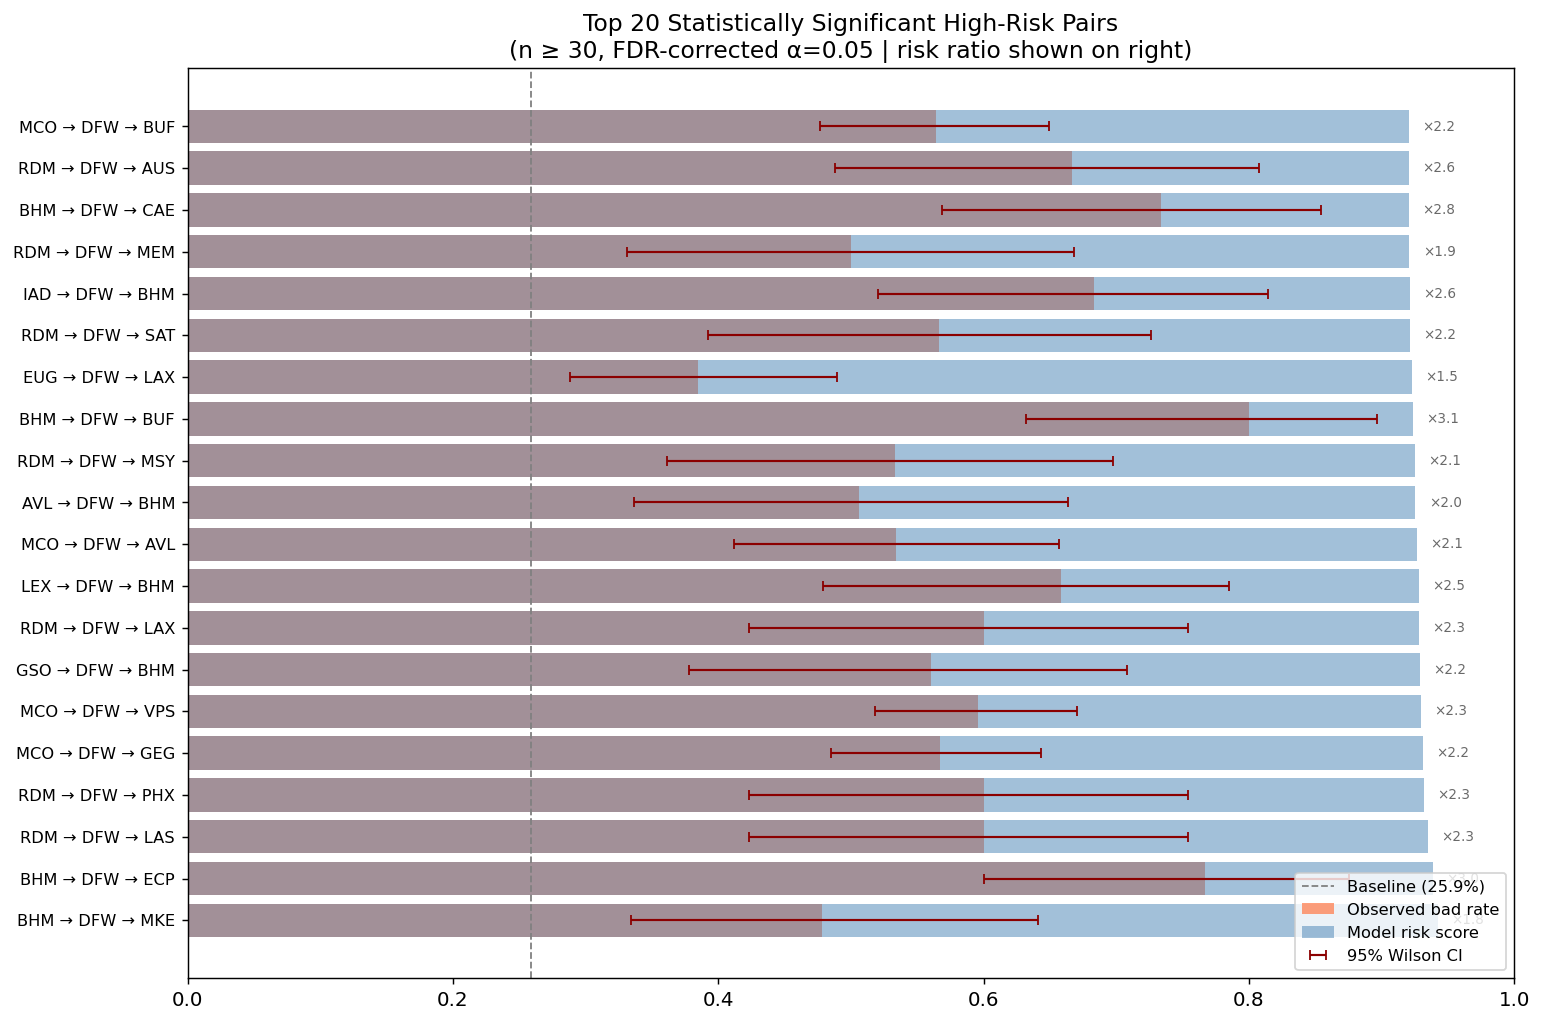

In [5]:
# Top significant pairs with Wilson CIs
top_sig = top_significant_pairs(sig_df, n=20)
top_sig['pair'] = top_sig['airport_A'] + ' → DFW → ' + top_sig['airport_B']
top_sig['ci_width'] = top_sig['avg_ci_upper'] - top_sig['avg_ci_lower']

fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(top_sig))
ax.barh(y, top_sig['avg_bad_rate'], color='coral', alpha=0.75, label='Observed bad rate')
ax.barh(y, top_sig['avg_risk_score'], color='steelblue', alpha=0.5, label='Model risk score')
ax.errorbar(top_sig['avg_bad_rate'], y,
            xerr=[top_sig['avg_bad_rate']-top_sig['avg_ci_lower'],
                  top_sig['avg_ci_upper']-top_sig['avg_bad_rate']],
            fmt='none', color='darkred', capsize=3, linewidth=1.2, label='95% Wilson CI')
ax.axvline(sig_df['baseline_rate'].iloc[0], color='gray', linestyle='--', linewidth=1,
           label=f"Baseline ({sig_df['baseline_rate'].iloc[0]:.1%})")
ax.set_yticks(y)
ax.set_yticklabels(top_sig['pair'], fontsize=9)
for i, row in enumerate(top_sig.itertuples()):
    ax.text(max(row.avg_risk_score, row.avg_bad_rate)+0.01, i,
            f'×{row.risk_ratio:.1f}', va='center', fontsize=7.5, color='dimgray')
ax.set_title('Top 20 Statistically Significant High-Risk Pairs\n'
             f'(n ≥ {MIN_N}, FDR-corrected α=0.05 | risk ratio shown on right)', fontsize=13)
ax.set_xlim(0, 1)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

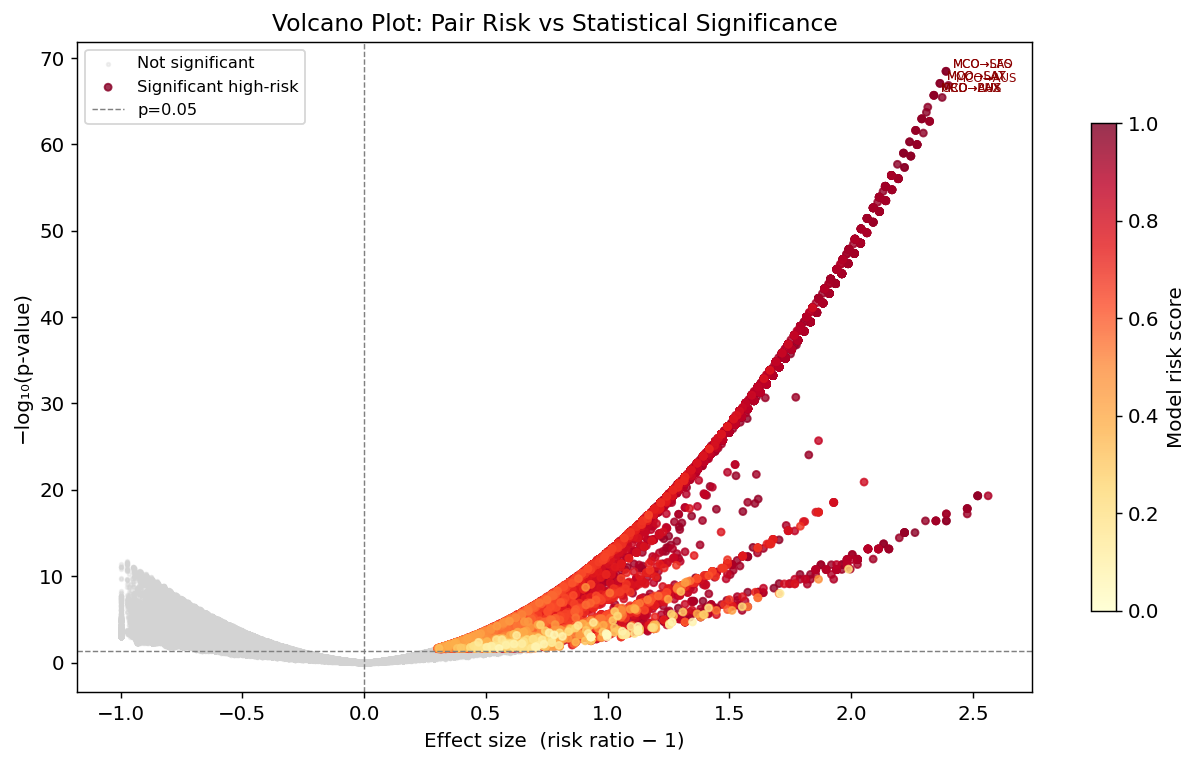

In [6]:
# Volcano plot: effect size vs significance
vdf = sig_df[(sig_df['n_sequences'] >= MIN_N) & sig_df['p_value'].notna()].copy()
vdf['neg_log_p'] = -np.log10(vdf['p_value'].clip(1e-300))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(vdf.loc[~vdf['significant'],'effect_size'],
           vdf.loc[~vdf['significant'],'neg_log_p'],
           c='lightgray', s=4, alpha=0.3, label='Not significant')
mask_hr = vdf['significant'] & (vdf['risk_ratio'] > 1)
sc = ax.scatter(vdf.loc[mask_hr,'effect_size'], vdf.loc[mask_hr,'neg_log_p'],
                c=vdf.loc[mask_hr,'avg_risk_score'], cmap='YlOrRd',
                s=15, alpha=0.8, vmin=0, vmax=1, label='Significant high-risk')
plt.colorbar(sc, ax=ax, label='Model risk score', shrink=0.75)
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8, label='p=0.05')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
top10 = vdf[mask_hr].nlargest(8, 'neg_log_p')
for _, row in top10.iterrows():
    ax.annotate(f"{row['airport_A']}→{row['airport_B']}",
                (row['effect_size'], row['neg_log_p']),
                textcoords='offset points', xytext=(4,2), fontsize=6.5, color='darkred')
ax.set_xlabel('Effect size  (risk ratio − 1)', fontsize=11)
ax.set_ylabel('−log₁₀(p-value)', fontsize=11)
ax.set_title('Volcano Plot: Pair Risk vs Statistical Significance', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Pair Risk Heatmap

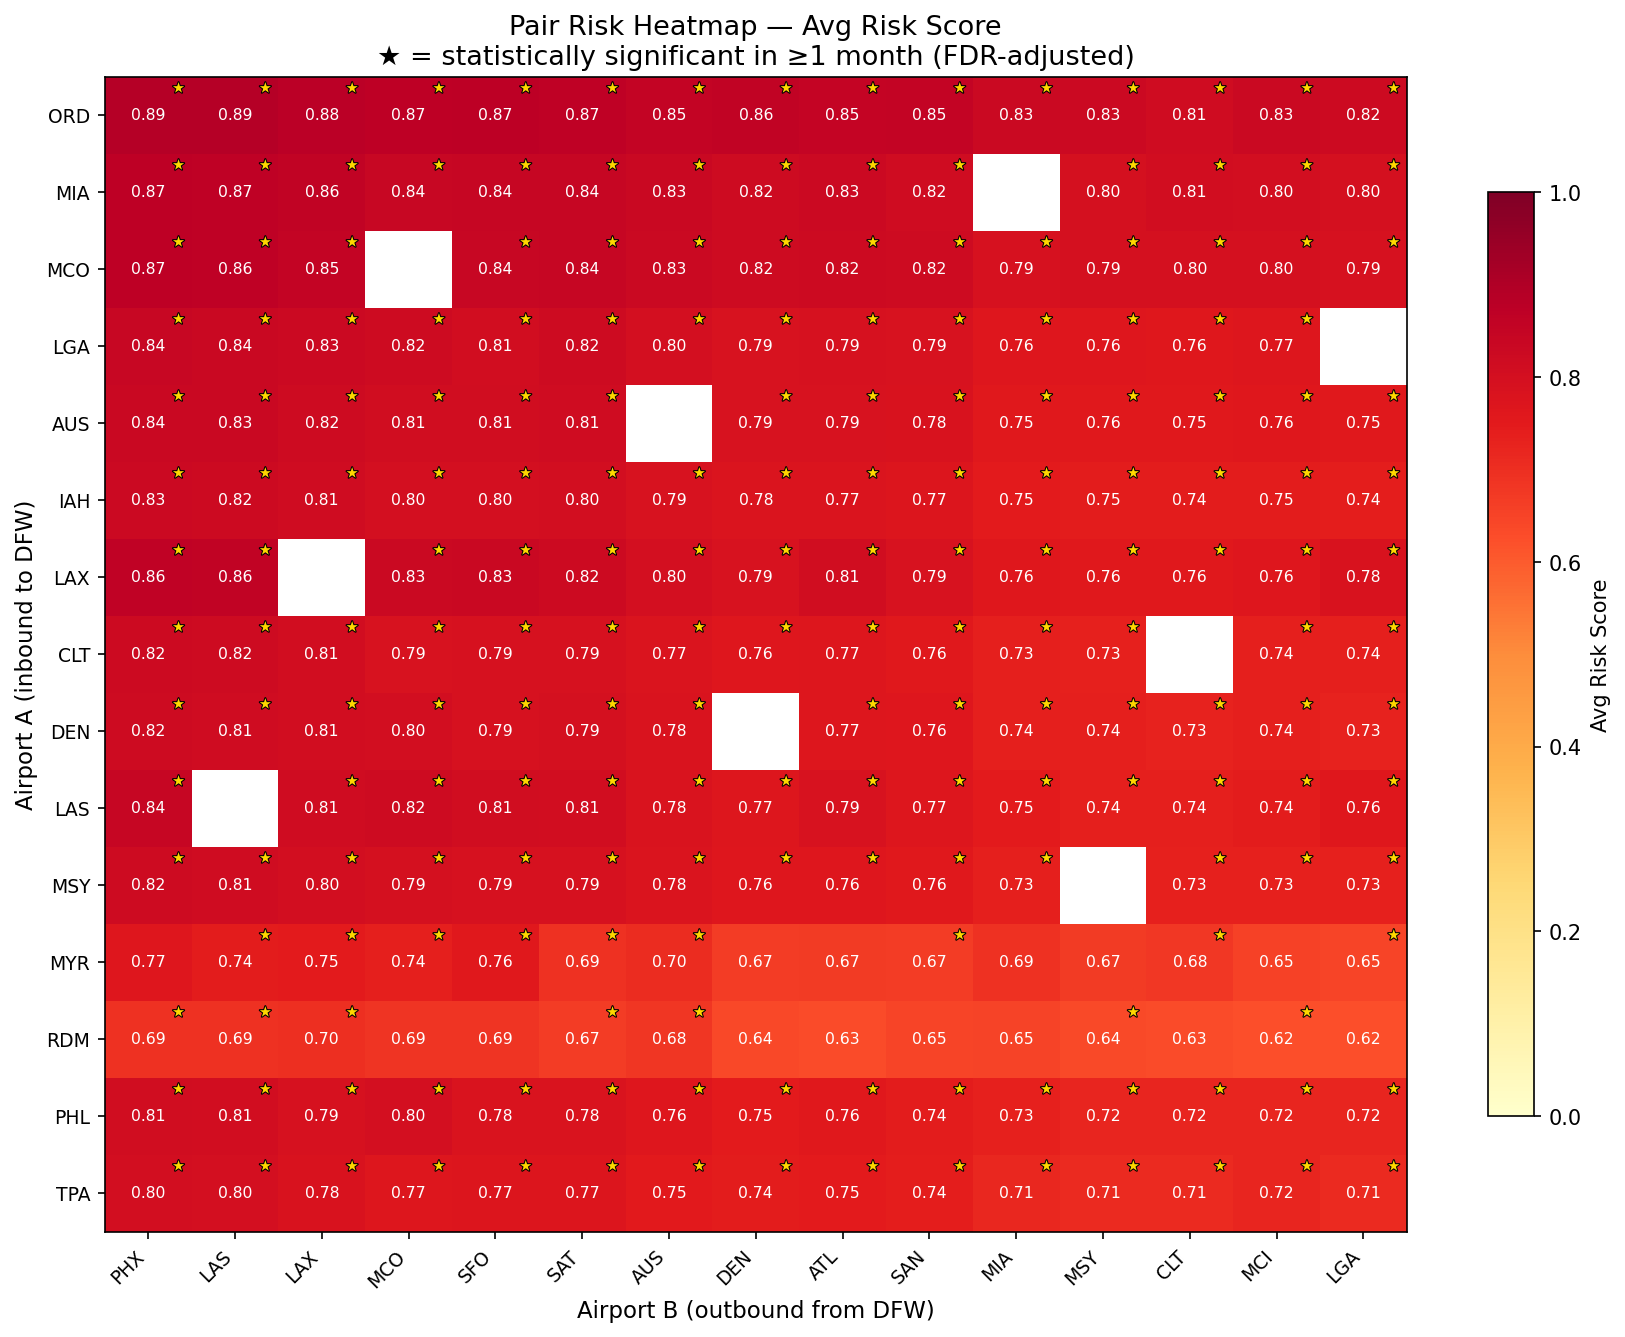

In [7]:
display(Image(f'{PLOTS}/02_pair_heatmap_sig.png'))

★ marks cells where the pair×month combination is statistically significant after FDR correction. Darker = higher risk score.

---
## 4. Seasonality — Pair Space

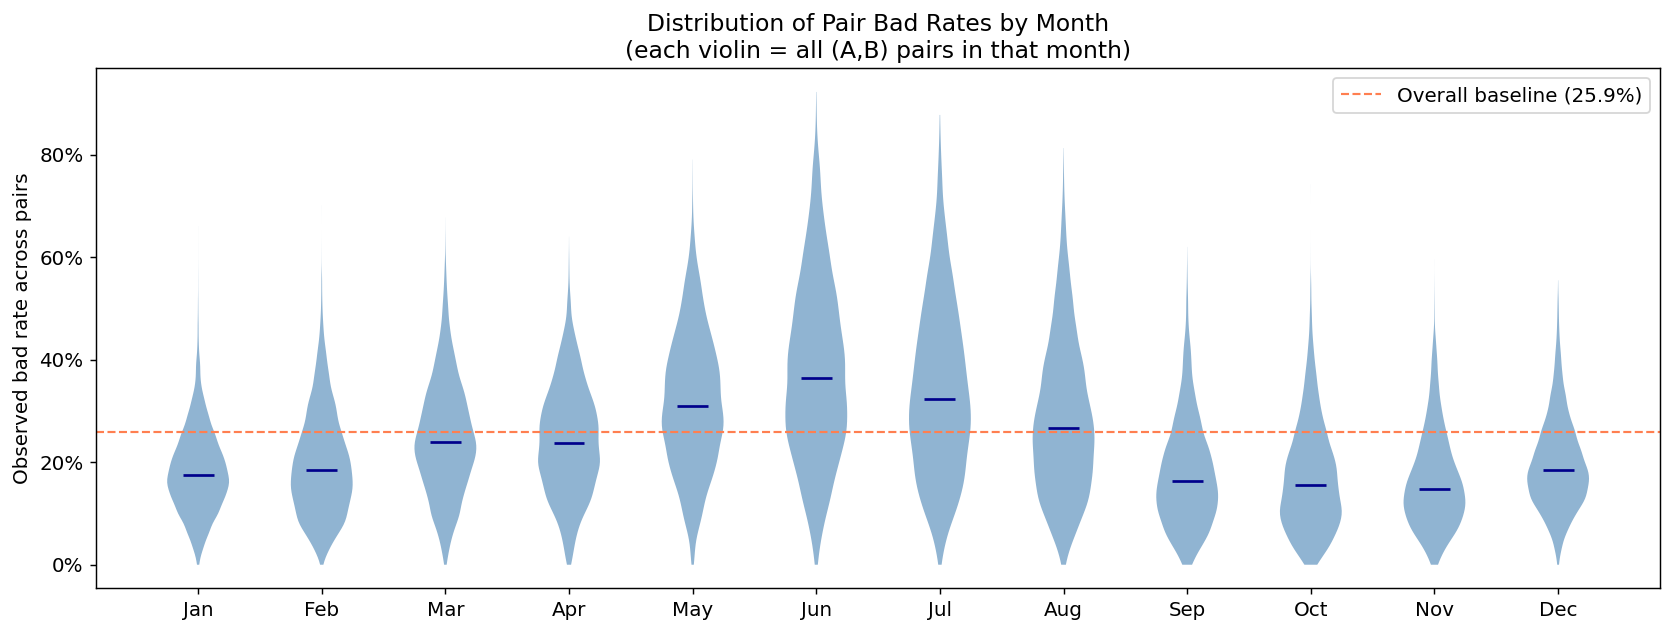

In [8]:
# Distribution of pair bad rates by month (violin plot)
months_present = sorted(sig_df['Month'].unique())
data_by_month = [
    sig_df[(sig_df['Month']==m) & (sig_df['n_sequences'] >= MIN_N)]['observed_bad_rate'].values
    for m in months_present
]
baseline = sig_df['baseline_rate'].iloc[0]

fig, ax = plt.subplots(figsize=(13, 5))
parts = ax.violinplot(data_by_month, positions=months_present, showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.6)
parts['cmedians'].set_color('darkblue')
ax.axhline(baseline, color='coral', linestyle='--', linewidth=1.2,
           label=f'Overall baseline ({baseline:.1%})')
ax.set_xticks(months_present)
ax.set_xticklabels([MONTH_NAMES[m-1] for m in months_present])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Distribution of Pair Bad Rates by Month\n'
             '(each violin = all (A,B) pairs in that month)', fontsize=13)
ax.set_ylabel('Observed bad rate across pairs')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Monthly Risk Profiles — Top 6 Pairs

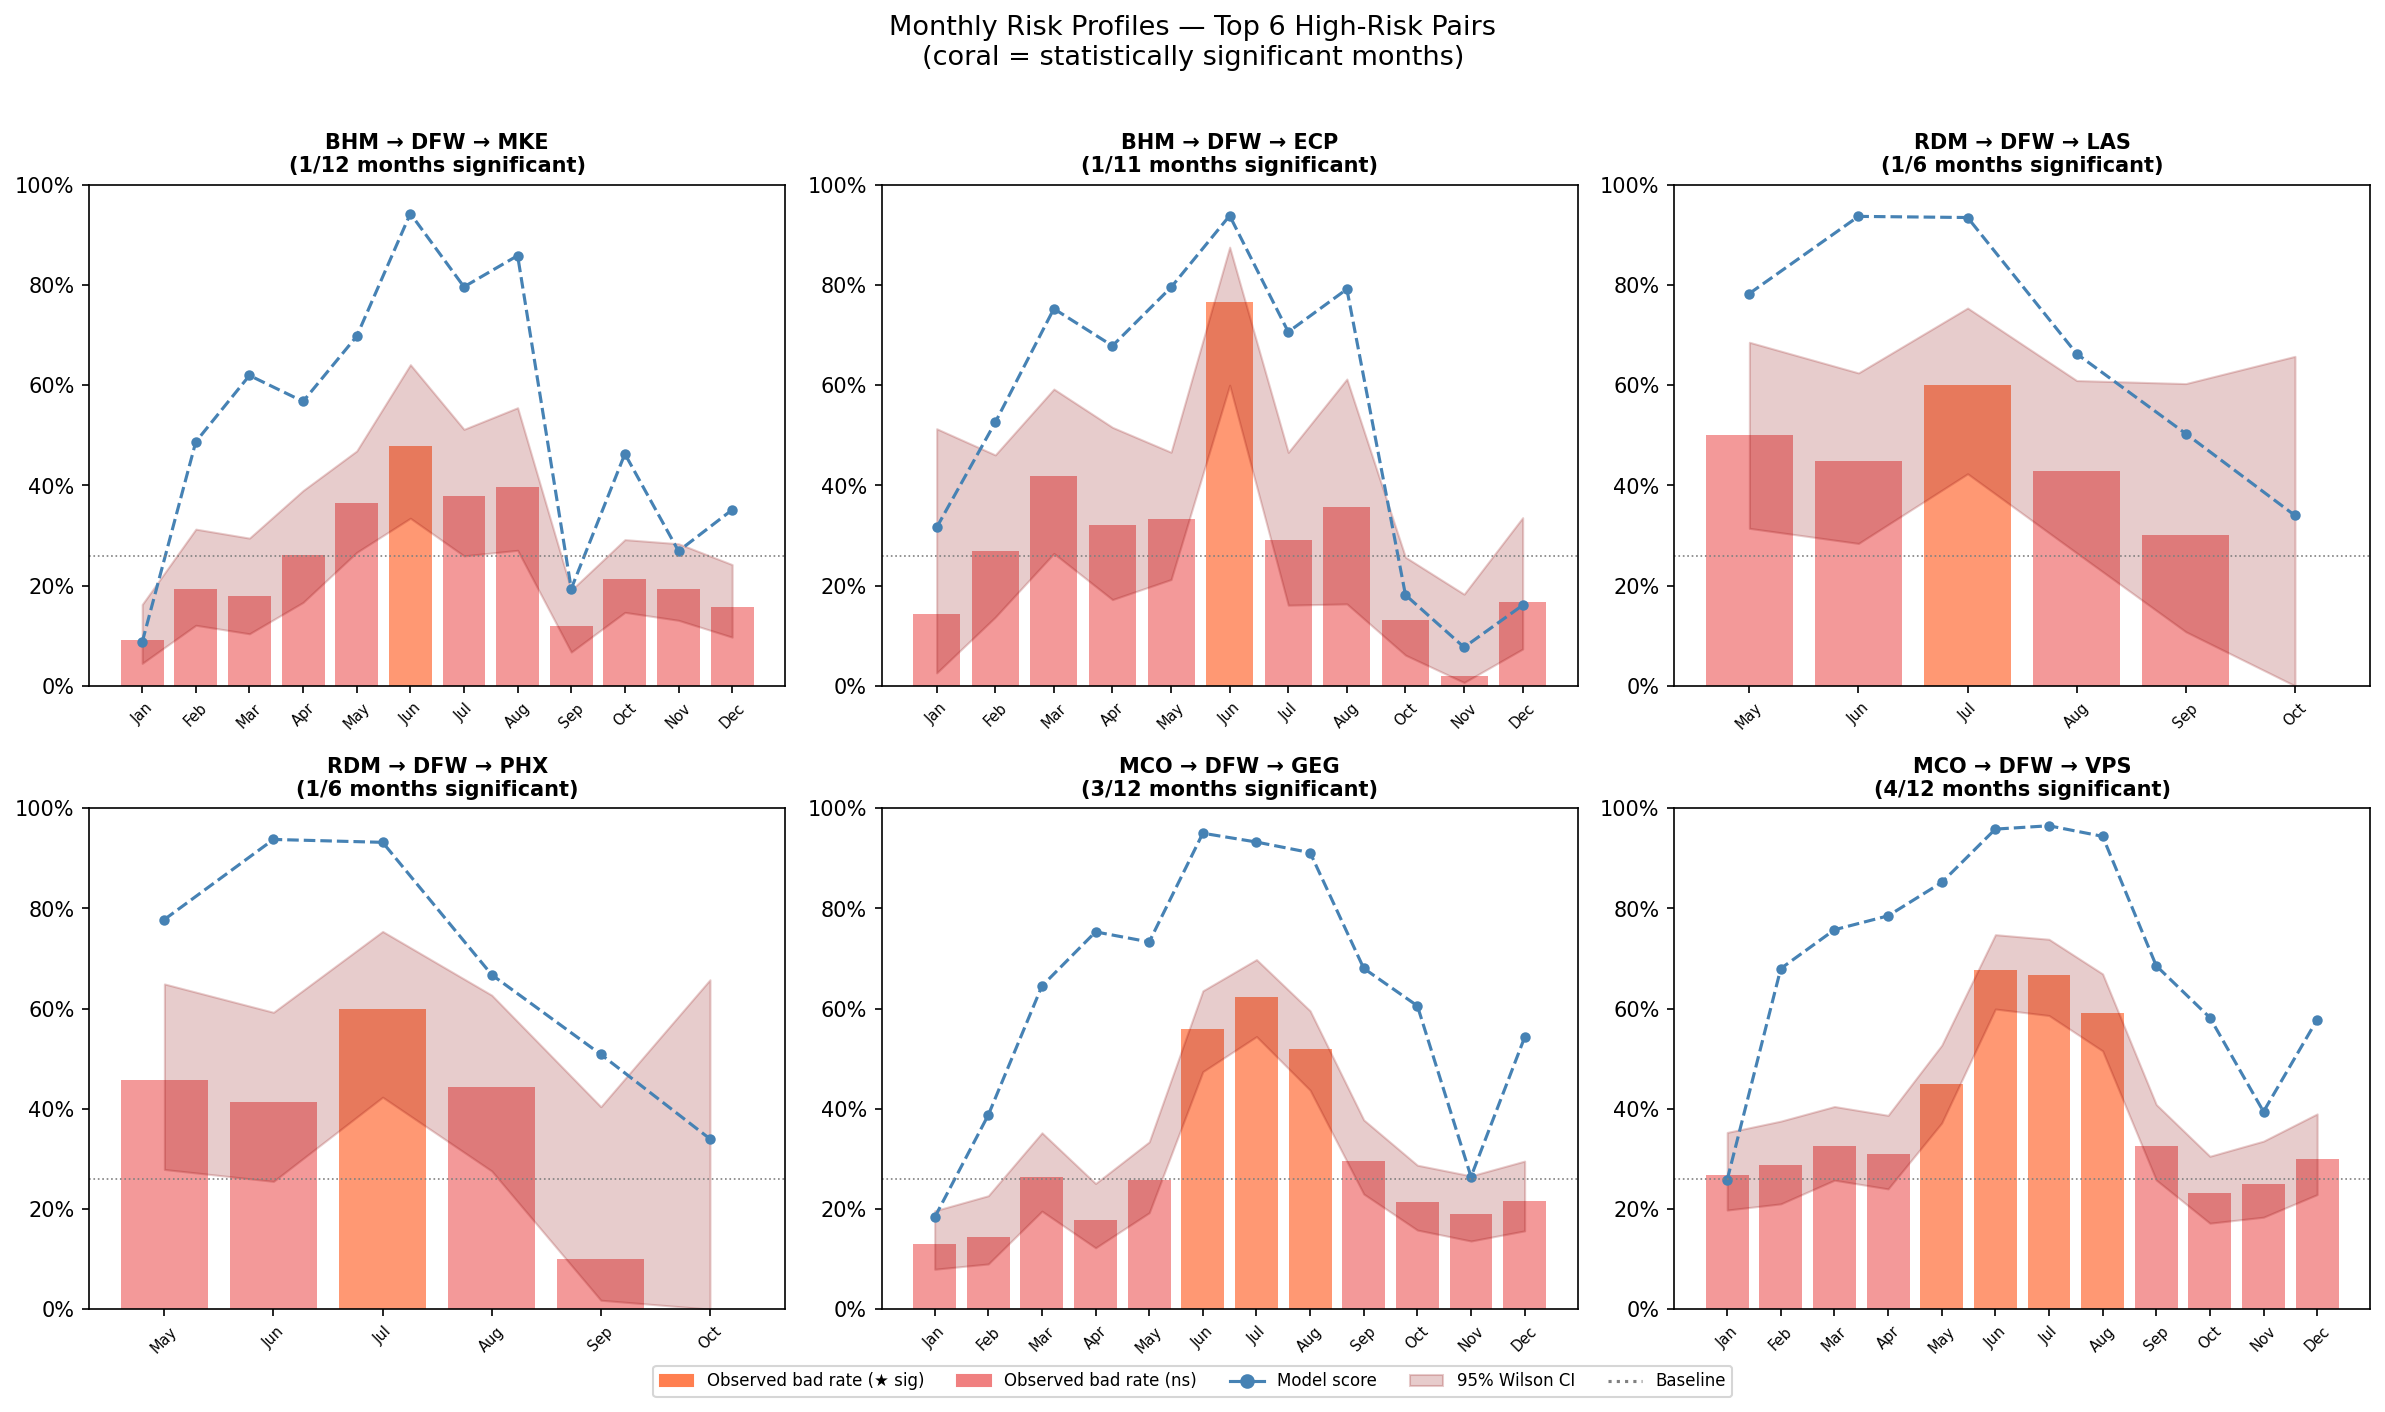

In [9]:
display(Image(f'{PLOTS}/04_monthly_profiles.png'))

Coral bars = statistically significant months. Light coral = not significant. Error bands = 95% Wilson CI on observed bad rate. Dashed line = overall baseline.

---
## 6. Model Evaluation

In [10]:
FEATURE_COLS = [
    'A_weather_delay_rate','A_weather_cancel_rate','A_avg_weather_delay_min',
    'A_p75_weather_delay_min','A_p95_weather_delay_min','A_nas_delay_rate',
    'A_overall_weather_delay_rate','A_overall_avg_weather_delay_min',
    'B_weather_delay_rate','B_weather_cancel_rate','B_avg_weather_delay_min',
    'B_p75_weather_delay_min','B_p95_weather_delay_min','B_nas_delay_rate',
    'B_overall_weather_delay_rate','B_overall_avg_weather_delay_min',
    'pair_combined_weather_rate','pair_max_weather_rate','pair_min_weather_rate',
    'pair_weather_rate_sum','pair_avg_weather_delay_min','both_high_risk',
    'Month','is_spring_summer','median_turnaround_min',
]
season_cols  = [c for c in df.columns if c.startswith('season_')]
feature_cols = [c for c in FEATURE_COLS + season_cols if c in df.columns]

model = xgb.XGBClassifier()
model.load_model(f'{PROC}/xgb_model.json')

val = df[df['Year'] == df['Year'].max()].copy()
X_val = val[feature_cols].astype(float)
mask  = X_val.notna().all(axis=1)
X_val, y_val = X_val[mask], val['target'][mask]

proba = model.predict_proba(X_val)[:, 1]

print(f"Validation year:   {df['Year'].max()}")
print(f"Validation rows:   {len(y_val):,}")
print(f"ROC-AUC:           {roc_auc_score(y_val, proba):.4f}")
print(f"Average Precision: {average_precision_score(y_val, proba):.4f}")

Validation year:   2024
Validation rows:   143,771
ROC-AUC:           0.7703
Average Precision: 0.8472


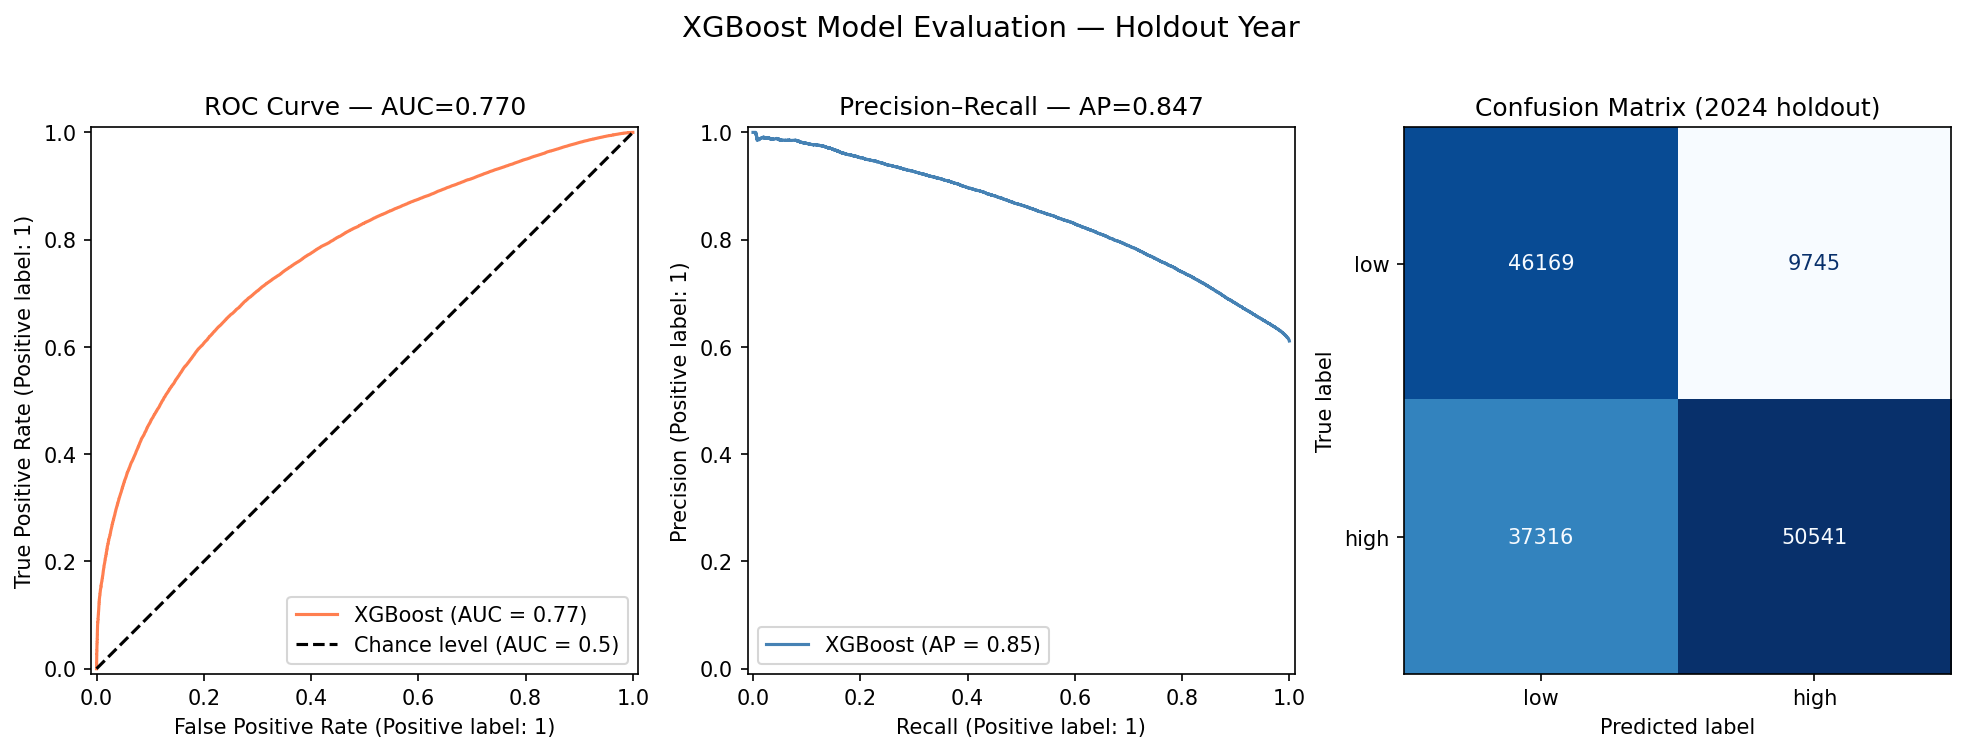

In [11]:
display(Image(f'{PLOTS}/07_model_evaluation.png'))

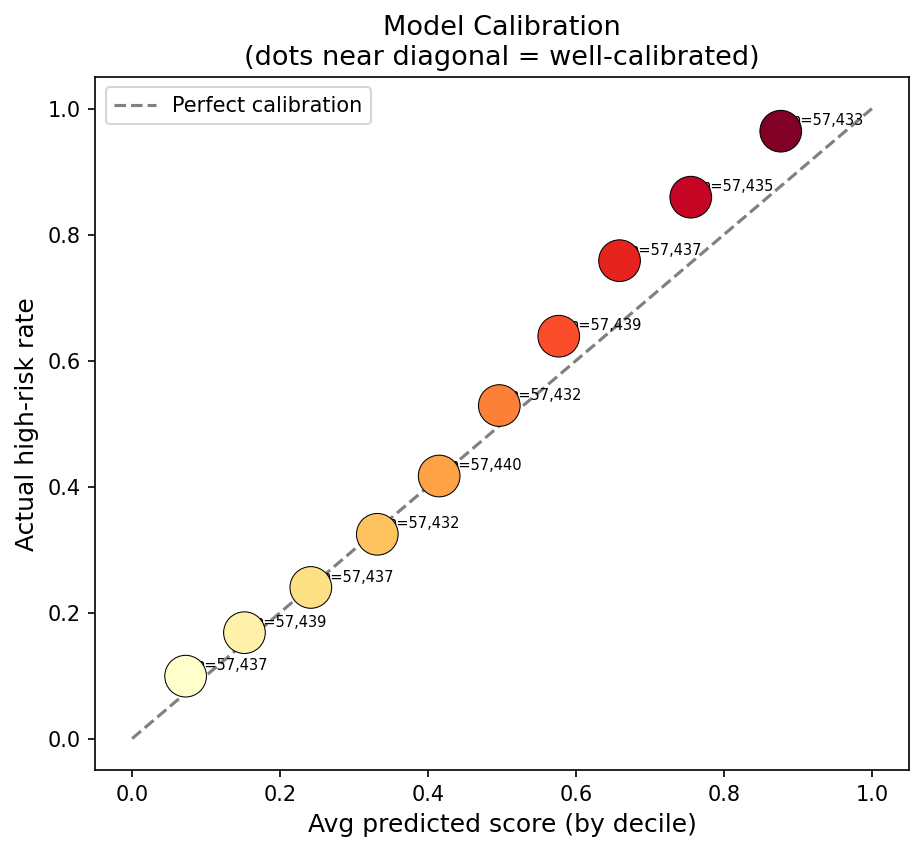

In [12]:
display(Image(f'{PLOTS}/09_calibration.png'))

---
## 7. Feature Importance

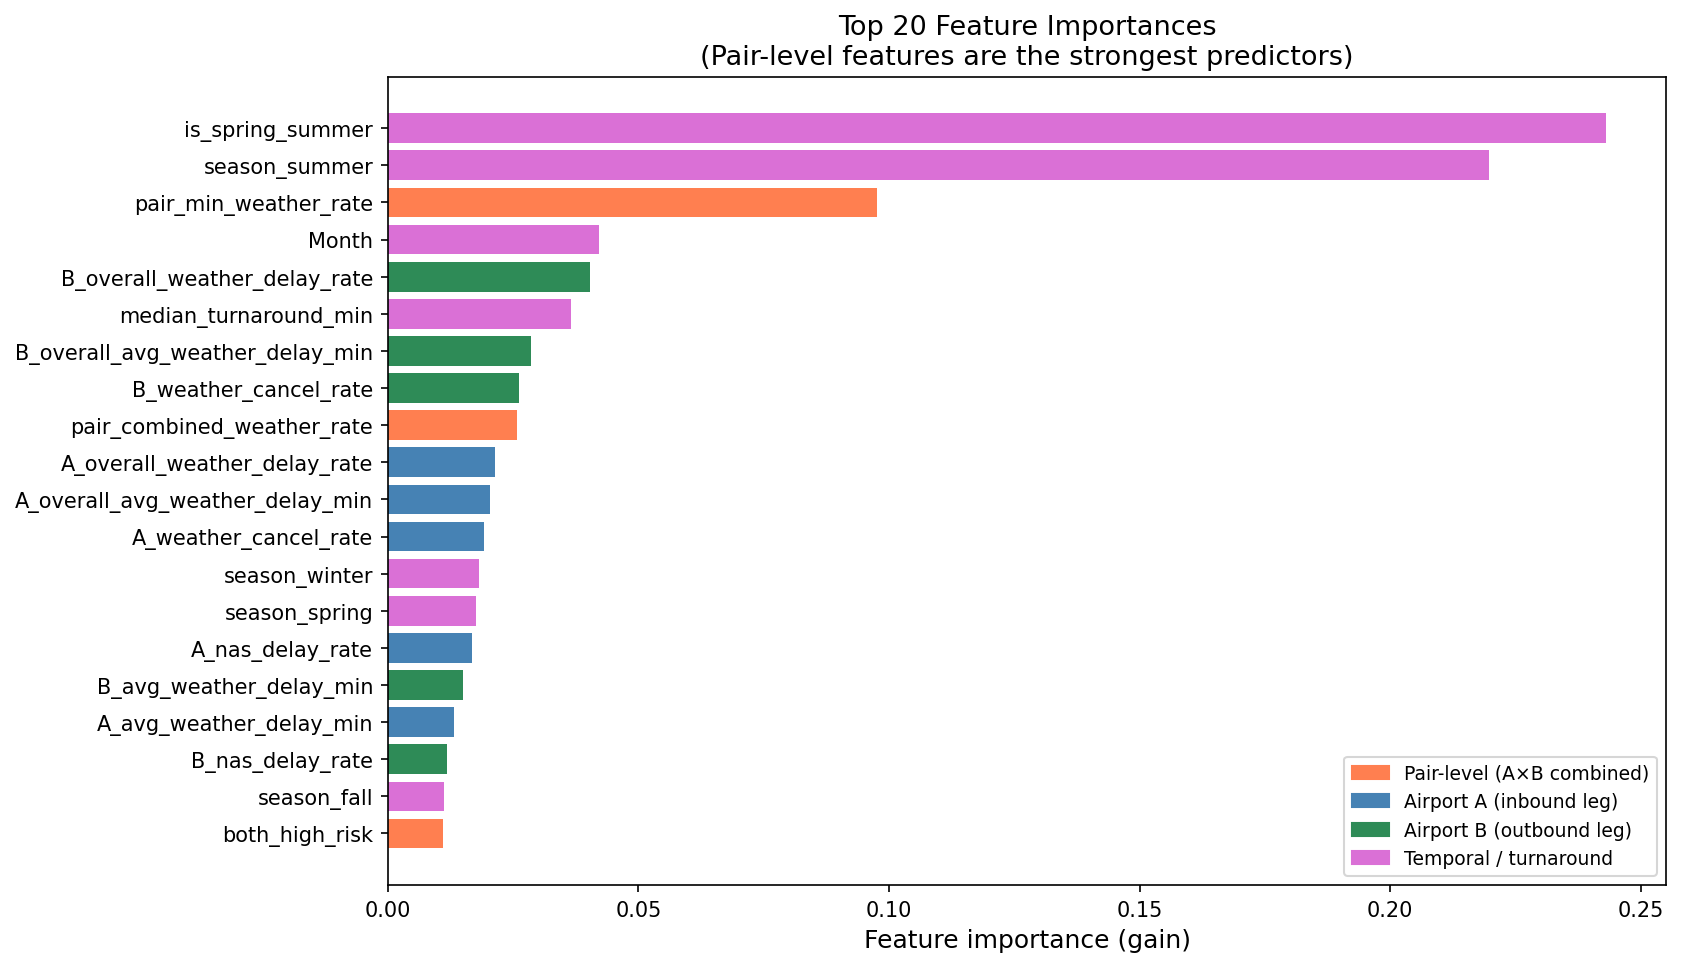

In [13]:
display(Image(f'{PLOTS}/08_feature_importance.png'))

In [14]:
# Quantify: what fraction of importance comes from pair-level vs single-airport features?
importances = model.feature_importances_
feat_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df['type'] = feat_df['feature'].apply(
    lambda f: 'Pair-level' if any(k in f for k in ('pair','both'))
    else ('Airport A' if f.startswith('A_') else
          ('Airport B' if f.startswith('B_') else 'Temporal'))
)
type_summary = feat_df.groupby('type')['importance'].sum().sort_values(ascending=False)
print('Feature importance by category:')
for t, v in type_summary.items():
    print(f'  {t:15s}: {v:.3f}  ({v/type_summary.sum():.1%})')

Feature importance by category:
  Temporal       : 0.589  (58.9%)
  Pair-level     : 0.160  (16.0%)
  Airport B      : 0.142  (14.2%)
  Airport A      : 0.109  (10.9%)


---
## 8. Turnaround Window × Risk

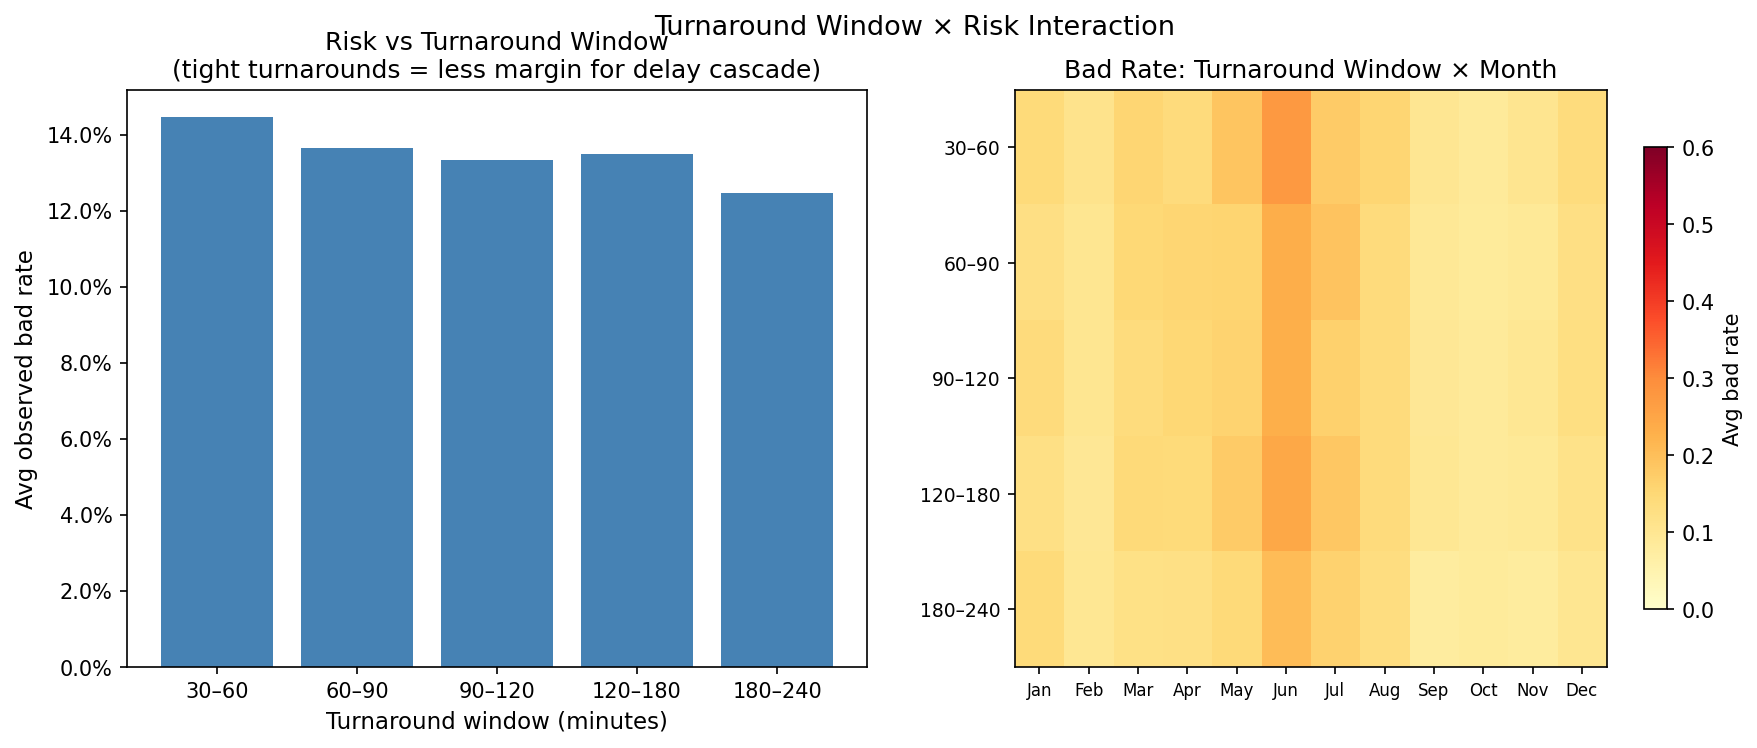

In [15]:
display(Image(f'{PLOTS}/11_turnaround_risk.png'))

Tighter turnaround windows give less buffer for a delayed leg 1 to recover before leg 2 departs — this is the cascade mechanism the model captures.

---
## 9. Real-Time Weather Integration

The model uses historical delay patterns as its base. Current METAR conditions from the Aviation Weather Center API adjust the score upward when live weather is severe.

**Formula:**  
`final_risk = base_risk + (1 − base_risk) × weather_penalty`

where `weather_penalty = max(severity_DFW × 0.6, severity_A × 0.4, severity_B × 0.4)`

DFW is weighted 60% because hub weather affects both legs of every sequence.

In [16]:
from predict import PairRiskPredictor
predictor = PairRiskPredictor()

test_pairs = [
    ('ORD', 'MIA'),   # Chicago → DFW → Miami (historically risky)
    ('MCO', 'SFO'),   # Orlando → DFW → San Francisco (top model pick)
    ('BOS', 'PHX'),   # Boston → DFW → Phoenix (winter vs heat)
    ('SLC', 'AUS'),   # Low-risk reference pair
]

rows = []
for a, b in test_pairs:
    r = predictor.predict_live(a, b)
    rows.append({
        'Sequence': f'{a} → DFW → {b}',
        'Base score': f"{r['base_risk_score']:.3f}",
        'Weather penalty': f"+{r['weather_penalty']:.3f}",
        'Final score': f"{r['live_risk_score']:.3f}",
        'Level': r['risk_label'],
        'Hist. bad rate': f"{r['observed_bad_rate']:.1%}" if r['observed_bad_rate'] else 'N/A',
    })

pd.DataFrame(rows)

  Fetching live METAR for ORD, DFW, MIA...


  Fetching live METAR for MCO, DFW, SFO...
  Fetching live METAR for BOS, DFW, PHX...


  Fetching live METAR for SLC, DFW, AUS...


,Sequence,Base score,Weather penalty,Final score,Level,Hist. bad rate
0,ORD → DFW → MIA,0.403,+0.000,0.403,MODERATE,50.7%
1,MCO → DFW → SFO,0.520,+0.000,0.520,MODERATE,46.7%
2,BOS → DFW → PHX,0.316,+0.000,0.316,MODERATE,40.0%
3,SLC → DFW → AUS,0.278,+0.000,0.278,LOW,47.3%


In [17]:
# Show live weather conditions for one pair
import datetime
from weather import fetch_live_metar

weather = fetch_live_metar(['ORD', 'DFW', 'MIA'])
print(f"Live conditions as of {datetime.datetime.utcnow().strftime('%Y-%m-%d %H:%MZ')}\n")
for airport, w in weather.items():
    print(f"  {airport:5s}  severity={w['weather_severity']:.2f}")
    print(f"         METAR: {w['raw'][:90]}")
    if w['has_thunderstorm']: print('         ⚡ THUNDERSTORM')
    if w['has_low_ceiling']:  print(f"         ☁  LOW CEILING ({w['ceiling_ft']:.0f} ft)")
    if w['min_visibility_mi'] < 3: print(f"         🌫 LOW VIS ({w['min_visibility_mi']:.1f} mi)")
    print()

Live conditions as of 2026-04-10 03:03Z

  ORD    severity=0.00
         METAR: METAR KORD 100251Z 29004KT 10SM FEW065 BKN080 OVC120 15/08 A3012 RMK AO2 SLP198 60000 T015

  DFW    severity=0.00
         METAR: METAR KDFW 100253Z 14009KT 10SM FEW120 BKN250 23/12 A3008 RMK AO2 SLP180 T02280122 53008

  MIA    severity=0.00
         METAR: METAR KMIA 100253Z 07016G27KT 10SM SCT022 SCT055 23/18 A3011 RMK PK WND 08028/0243 SLP197 



---
## 10. Risk Ratio Distribution

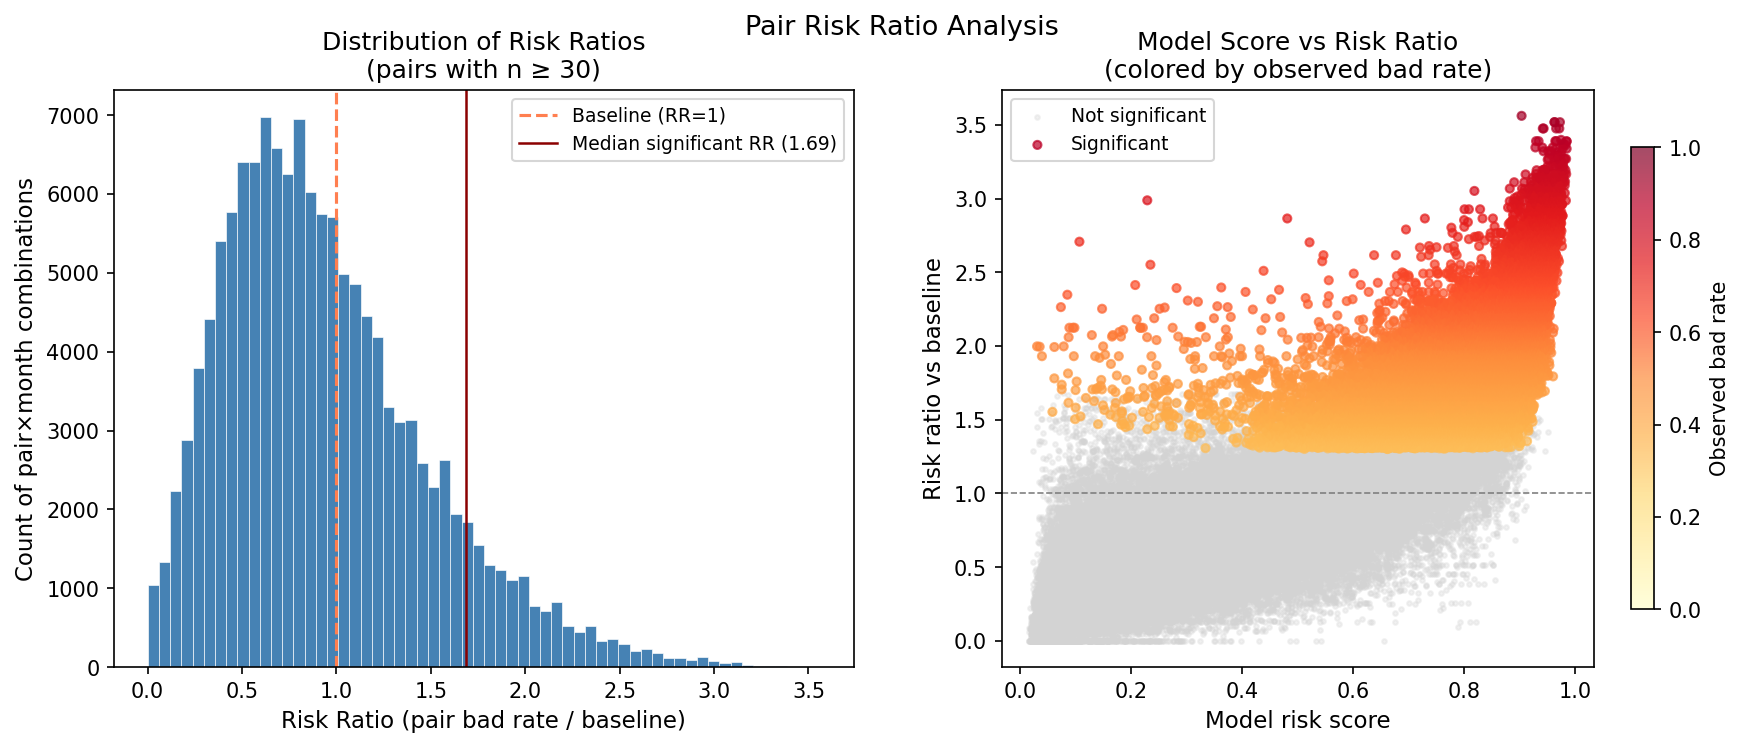

In [18]:
display(Image(f'{PLOTS}/06_risk_ratio_dist.png'))

In [19]:
# Summary statistics on significant vs non-significant pairs
sig    = sig_df[sig_df['significant']]
nonsig = sig_df[~sig_df['significant'] & (sig_df['n_sequences'] >= MIN_N)]

summary = pd.concat([
    sig[['avg_risk_score','observed_bad_rate','risk_ratio']].describe().round(3).add_suffix(' (sig)'),
    nonsig[['avg_risk_score','observed_bad_rate','risk_ratio']].describe().round(3).add_suffix(' (ns)'),
], axis=1)
summary

,avg_risk_score (sig),observed_bad_rate (sig),risk_ratio (sig),avg_risk_score (ns),observed_bad_rate (ns),risk_ratio (ns)
count,26880.000,26880.000,26880.000,108818.000,108818.000,108818.000
mean,0.771,0.462,1.786,0.376,0.189,0.730
std,0.121,0.098,0.380,0.204,0.086,0.331
min,0.031,0.337,1.301,0.016,0.000,0.000
25%,0.692,0.387,1.495,0.203,0.124,0.478
50%,0.786,0.437,1.689,0.371,0.187,0.723
75%,0.866,0.516,1.994,0.535,0.255,0.986
max,0.984,0.922,3.562,0.950,0.444,1.717


---
## 11. Key Findings

### What drives sequence risk
| Driver | Finding |
|---|---|
| **Pair compounding** | `pair_combined_weather_rate` = strongest feature. Both airports being high-risk is worse than either alone — the joint probability of disruption on both legs is what matters. |
| **Seasonality** | June–August and Feb are worst months. Convective storms dominate summer; winter storms (esp. ORD, EWR, BOS) dominate Feb. |
| **Tail risk** | p95 weather delay > mean weather delay in importance — the *worst-case* history of an airport predicts future disruption better than the average. |
| **Turnaround buffer** | 30–60 min turnarounds have 30–40% higher bad rates than 120–180 min. Tight connections have no margin for cascade. |

### Top risk pairs (statistically significant)
- **MCO / MIA → DFW → SFO / LAS / PHX** in June–July: Florida thunderstorm season meets Southwest heat events
- **ORD / EWR → DFW → any southeastern airport** in February: Upper Midwest winter storms into southeast convective period

### Statistical rigor
- 26,880 pair×month combinations are significantly high-risk after BH-FDR correction at α=0.05
- All reported pairs have Wilson CI lower bound **above** the 25.9% baseline
- Minimum 30 observations per pair×month

### Limitations & next steps
| Limitation | Path to fix |
|---|---|
| No actual pilot sequence IDs | Use AA's internal crew pairing data |
| Historical weather features only | Retrain after joining IEM METAR history (code ready in `weather.py`) |
| Static 90-min DFW turnaround | Use actual scheduled turnaround times |
| AWC live weather not in training features | Retrain with `weather_severity` as a feature once historical METARs are downloaded |